In [1]:
import pandas as pd

In [2]:
hogares=pd.read_csv('conjunto_de_datos_endutih_2024_csv/conjunto_de_datos/tr_endutih_hogares_anual_2024.csv')

C:\Users\Alejandra\AppData\Local\Temp\ipykernel_25228\3041956544.py:1: DtypeWarning: Columns (29,35,94) have mixed types. Specify dtype option on import or set low_memory=False.
  hogares=pd.read_csv('conjunto_de_datos_endutih_2024_csv/conjunto_de_datos/tr_endutih_hogares_anual_2024.csv')


In [3]:
diccionario_hogares=pd.read_csv('conjunto_de_datos_endutih_2024_csv/diccionario_de_datos/diccionario_de_datos_tr_endutih_hogares_anual_2024.csv')

In [4]:
hogares = hogares.astype({ #The columns that have mixed data types are converted to strings.
    'P4_6A': str,
    'P4_6_3': str,
    'P5_13A': str,
})

In [5]:
hogares.info() #Information of the dataframe is obtained.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58080 entries, 0 to 58079
Columns: 104 entries, UPM to ESTATUS
dtypes: float64(57), int64(38), object(9)
memory usage: 46.1+ MB


# Data cleaning

In [7]:
#The following code write the columns with NA in a .txt file
na_count = hogares.isna().sum()
lista_columnas_con_na = []
for i, (col, count) in enumerate(na_count.items()):
    pregunta = diccionario_hogares.iloc[i,1]
    lista_columnas_con_na.append(f"{i}; {col}; {pregunta.replace("\n", " ")}; {count} \n")


with open("Columns_with_na.txt", "w", encoding="utf-8") as f:
    f.writelines(lista_columnas_con_na)

*To analise the following questions and unsderstand the reasons of null values. The diagram of the survey was consulted.*

**The following groups of questions if people answered they did not have an item, they could not answered how many items they had neither their characteristics. That was the reason, in the following questons, the number of "NO" of the first question, and the number of NULL values of the following questions are the same.**

Group 1
P4_1_4; 4.1 Please let me know if you have the following items available: Flat-screen TV (digital television, LCD, or LED); "NO" = 9735

P4_1_4_1; 4.1 Please let me know if you have the following items available: Flat-screen TV (digital television, LCD, or LED). In total, how many flat-screen TVs do you have?; 9735  NULL
; P4_1_4_2; 4.Please let me know if you have the following items available: Flat-screen TV (digital television, LCD, or LED). In total, how many flat-screen TVs do you have? How many of these have Smart TV features (that connect directly to the internet or via a device)?)?; 9735 NULL

Group 2

P4_1_6; 4.1 Please let me know if you have the following items available: Mobile cell phone (owned by any member of the household).;"NO" = 2848 1; P4_1_6_1; 4Please let me know if you have the following items available: Mobile cell phone (owned by any member of the household). In total, how many cell phones are there in the household?ar?; 2 NULL842; P4_1_6_2; 4Please let me know if you have the following items available: Mobile cell phone (owned by any member of the household). How many of these are smartphones?e)?; 2 NULL848

Group 3

P4_2_1_1; 4.2 Do you have… a desktop computer (with the keyboard, monitor, and CPU as separate components)?; "NO" = 51637

P4_2_1_2; 4.2 Do you have a desktop computer (with the keyboard, monitor, and CPU as separate components)? How many desktop computers do you have?; 51637 null

Group 4

P4_2_2_1; 4.2 Do you have a laptop computer (with the keyboard, monitor, and CPU physically integrated)?; "NO" = 38381

P4_2_2_2; 4.2 Do you have a desktop computer (with the keyboard, monitor, and CPU as separate components)? How many laptop computers do you have?; 38381

Group 5

P4_2_3_1; 4.2 Do you have a tablet (with a virtual keyboard and stylus on the touchscreen)?; "NO" = 48376

P4_2_3_2; 4.2 Do you have a desktop computer (with the keyboard, monitor, and CPU as separate components)? How many tablets do you have?; 48376

The null values are raplaced by 0

In [16]:
hogares[['P4_1_4_1', 'P4_1_4_2', 'P4_1_6_1', 'P4_1_6_2', 'P4_2_1_2', 'P4_2_2_2' ,'P4_2_3_2']] = hogares[['P4_1_4_1', 'P4_1_4_2', 'P4_1_6_1', 'P4_1_6_2', 'P4_2_1_2' , 'P4_2_2_1','P4_2_3_2']].fillna(0)

## Null values for P4_3, 4.3 Why don’t you have a computer, laptop, or tablet?

For the question *P4_3, 4.3 Why don’t you have a computer, laptop, or tablet?*, it was analised that it should not be null values when one of the following questions have as answer "NO"  
P4_2_1_1  4.2 Do you have a desktop computer (with separate keyboard, monitor, and CPU)?  
P4_2_2_1  4.2 Do you have a laptop (with the keyboard, monitor, and CPU built into one unit)?  
P4_2_3_1  4.2 Do you have a tablet (with an on-screen virtual keyboard and pointer)?

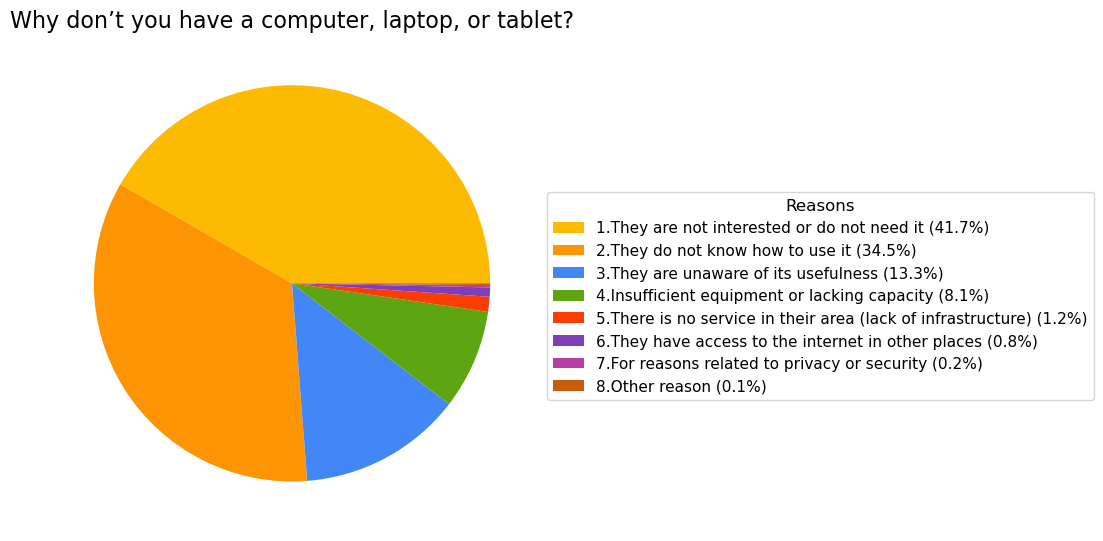

In [19]:
import matplotlib.pyplot as plt
counts = hogares['P4_3'].value_counts()

percentages = counts / counts.sum() * 100


fig, ax = plt.subplots(figsize= (10, 8))

pie_labels = [
    '1.They are not interested or do not need it',
    '2.They do not know how to use it',
    '3.They are unaware of its usefulness',
    '4.Insufficient equipment or lacking capacity',
    '5.There is no service in their area (lack of infrastructure)',
    '6.They have access to the internet in other places',
    '7.For reasons related to privacy or security',
    '8.Other reason'
        ]

pie_colors = ['#fcba03', '#fc9403', '#4287f5', '#5ea611',
              '#fc3d03', '#7d3eb8', '#b83ea5', '#c75c0a']

legend_labels = [
    f"{label} ({pct:.1f}%)"
    for label, pct in zip(pie_labels, percentages)
        ]
wedges, _  = ax.pie(counts, labels= None, colors= pie_colors)

# Leyenda
ax.legend(
    wedges,
    legend_labels,
    title="Reasons",
    bbox_to_anchor=(1, 0.7),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Why don’t you have a computer, laptop, or tablet?',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [20]:
#It counts the number of null vallues when the question P4_3 when P4_2_1_1, P4_2_2_1 or P4_2_3_1 were answered with "NO"
conteo = (
    ((hogares['P4_2_1_1'] == 2) |
    (hogares['P4_2_2_1'] == 2) |
    (hogares['P4_2_3_1'] == 2)
    ) &
    (hogares['P4_3'].isna())
).sum()
print(f'Number of null values in question P4_3: {conteo}')

Number of null values in question P4_3: 23372


In this case, the answer P4_3 it will be treated as a classification problem to obtain the missing values of the question P4_3

In [51]:
#A new data frame is created base in the original data frame
data_P4_3_sinNA = hogares.iloc[:, 0:20].dropna()
data_P4_3_sinNA.head()


,UPM,VIV_SEL,HOGAR,P4_1_1,P4_1_2,P4_1_3,P4_1_4,P4_1_4_1,P4_1_4_2,P4_1_5,P4_1_6,P4_1_6_1,P4_1_6_2,P4_2_1_1,P4_2_1_2,P4_2_2_1,P4_2_2_2,P4_2_3_1,P4_2_3_2,P4_3
1,100110,2,1,1,2,1,1,1.0,1.0,2,1,1.0,0.0,2,0.0,2,2,2,0.0,2.0
2,100110,3,1,2,2,1,1,3.0,2.0,2,1,7.0,7.0,2,0.0,2,2,2,0.0,5.0
3,100110,4,1,2,2,2,2,0.0,0.0,2,1,1.0,1.0,2,0.0,2,2,2,0.0,2.0
4,100110,5,1,2,2,2,1,2.0,2.0,1,1,3.0,3.0,2,0.0,2,2,2,0.0,1.0
11,100140,2,1,2,2,2,1,1.0,1.0,2,1,3.0,3.0,2,0.0,2,2,2,0.0,1.0


In [53]:
#Libraries are indicated to build a model
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [57]:
#The dataset is prepared
X = data_P4_3_sinNA.drop(columns='P4_3') #The objective column is drop
y = data_P4_3_sinNA['P4_3'] #The objective column is indicate
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, #The proprtions of the treaning dataset are indicated 80% of the dataset
    random_state=42,
    stratify=y
)

In [59]:
#The model is built
classifier = tree.DecisionTreeClassifier()
classifier.fit(X_train, y_train)
print("The trainnig has finished")

The trainnig has finished


In [61]:
#The model's performance is meassure
predicted_reasons = classifier.predict(X_test)
print(classification_report(y_test, predicted_reasons ))

              precision    recall  f1-score   support

         1.0       0.47      0.47      0.47      2741
         2.0       0.39      0.40      0.40      2272
         3.0       0.27      0.26      0.26       877
         4.0       0.11      0.12      0.12       535
         5.0       0.03      0.02      0.03        81
         6.0       0.00      0.00      0.00        12
         7.0       0.05      0.06      0.06        49
         8.0       0.14      0.22      0.17         9

    accuracy                           0.38      6576
   macro avg       0.18      0.19      0.19      6576
weighted avg       0.38      0.38      0.38      6576

